# Application 3 — Segmentation Transfer

A **segmentation** is a per-vertex integer label (body part, anatomical region, tissue type).
Once we have a point-to-point correspondence, transferring a segmentation is a single index operation:
`seg_b[i] = seg_a[p2p[i]]`.

This notebook uses cat → lion as placeholder.
**To use brain or organ shapes**: replace the data loading section and the
segmentation definition with your own labels.
The rest of the pipeline is identical.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pyvista as pv

import geomfum
from geomfum.dataset import NotebooksDataset
from geomfum.shape import TriangleMesh

notebooks_dir = Path(geomfum.__file__).resolve().parents[1] / "notebooks"
if str(notebooks_dir) not in sys.path:
    sys.path.insert(0, str(notebooks_dir))

from plot_utils import show_segmentation  # noqa: E402

pv.set_jupyter_backend("static")

## 1. Load shapes


In [2]:
dataset = NotebooksDataset()
mesh_a = TriangleMesh.from_file(
    dataset.get_filename("brain_template")
)  # source with known landmarks
mesh_b = TriangleMesh.from_file(dataset.get_filename("brain_subject"))  # target
# centering
mesh_a.vertices -= mesh_a.vertices.mean(axis=0)
mesh_b.vertices -= mesh_b.vertices.mean(axis=0)
label_a = np.loadtxt(dataset.get_filename("template_labels")).astype(int)

## 2. Compute correspondence (FM pipeline)

In [3]:
from geomfum.convert import NeighborFinder

knn = NeighborFinder()
p2p = knn(mesh_b.vertices, mesh_a.vertices).flatten()

## 3. Transfer segmentation to the target

In [4]:
label_b = label_a[p2p]  # single index operation — that's it

## 5. Visualise segmentation on both shapes

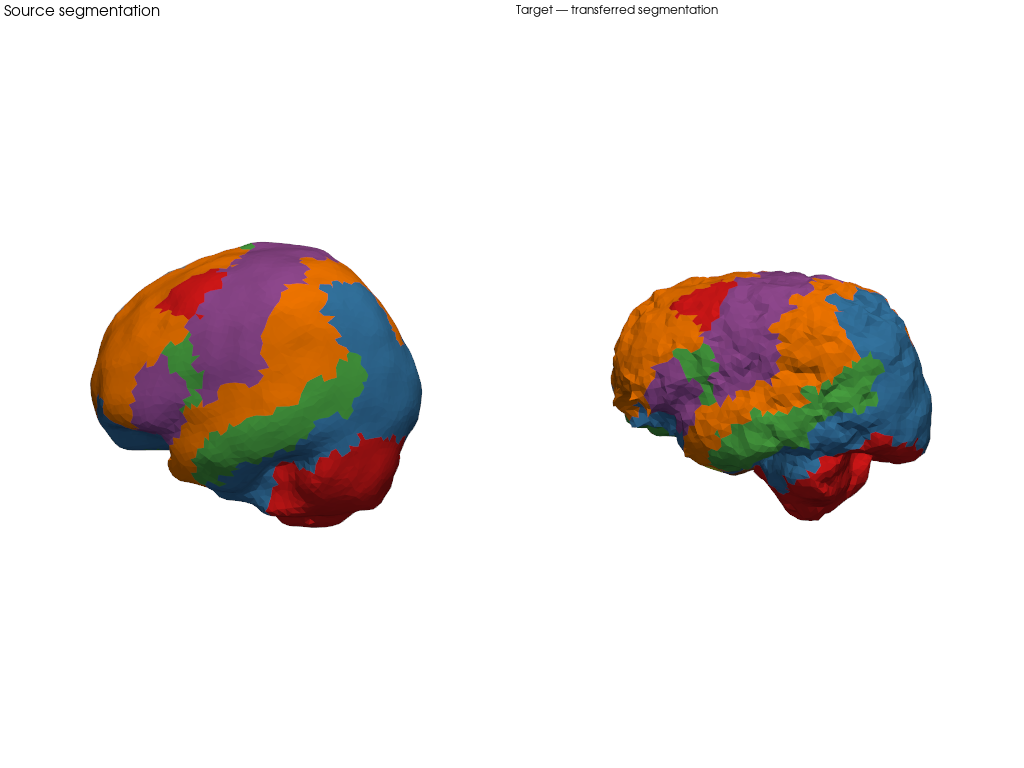

In [5]:
show_segmentation(
    vertices_list=[mesh_a.vertices, mesh_b.vertices],
    faces_list=[mesh_a.faces, mesh_b.faces],
    labels_list=[label_a, label_b],
    titles=["Source segmentation", "Target — transferred segmentation"],
)

Corresponding anatomical regions should carry the same color on both shapes.
Errors (miscolored patches) reflect local inaccuracies in the FM correspondence.